# SIF (Structured Insight Framework) with Exploratory Data Analysis for the Netflix Datase using the Star Schema Model -Aira

## 1. 🚀 DEFINE ANALYTICAL QUESTIONS 

### 1.  Performance (fact_weekly_performance)
- What defines a “hit”?
- Do top-ranked shows sustain or decay?

### 2.  Geography (dim_country)
- Do countries behave differently?
- Is there a Nordic pattern?

### 3. Time (dim_date)
- How long do shows stay relevant?
- Are there seasonal spikes?
  
### 4. Content (dim_show + dim_category)
- Films vs TV → which dominates?
- Which genres perform best?

## 📊 Define Metrics - Core KPI Layer for the Popularity of a show | Performance Score
semantic contract for all visuals

| Metric                | Definition                                      | Formula                                                  |
|---------------------|-----------------------------------------------|----------------------------------------------------------|
| Popularity / Performance Score | Combines rank and longevity into one score | (11 - weekly_rank) * log(1 + cumulative_weeks)           |
| Longevity           | Total time a show stays in Top 10             | max(cumulative_weeks_in_top_10)                          |
| Average Rank        | Average ranking position over time            | mean(weekly_rank)                                        |
| Scale               | Total viewing volume                          | sum(weekly_views)                                        |
| Engagement Intensity| Views per week while in Top 10                | total_views / weeks_in_top10                             |

## 📊 EDA LAYER

In [38]:
import pandas as pd
import duckdb
from pathlib import Path   
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import seaborn as sns
import squarify

p = Path().resolve()

for i, parent in enumerate(p.parents):
    print(i, parent)

0 C:\Users\adelo\de25\Netflix_Analytics_DE_UX\eda
1 C:\Users\adelo\de25\Netflix_Analytics_DE_UX
2 C:\Users\adelo\de25
3 C:\Users\adelo
4 C:\Users
5 C:\


In [ ]:
# Fix Path
BASE_DIR = Path().resolve().parents[1]   # ✅ correct level
MODEL_DIR = BASE_DIR / "data" / "processed" / "model"

print(MODEL_DIR)

C:\Users\adelo\de25\Netflix_Analytics_DE_UX\data\processed\model


In [ ]:
# Validate the tables exist in the Path
print((MODEL_DIR / "dim_show.csv").exists())

True


In [ ]:
# Register All Tables

con = duckdb.connect()

def register(table_name):
    path = (MODEL_DIR / table_name).as_posix()
    
    con.execute(f"""
    CREATE OR REPLACE VIEW {table_name.replace('.csv','')} AS 
    SELECT * FROM read_csv_auto('{path}');
    """)

tables = [
    "dim_show.csv",
    "dim_date.csv",
    "dim_country.csv",
    "dim_category.csv",
    "dim_genre.csv",
    "bridge_show_genre.csv",
    "fact_weekly_performance.csv",
    "fact_alltime.csv"
]

for t in tables:
    register(t)

In [13]:
# Sanity Check for tables

con.execute("SELECT COUNT(*) FROM dim_show").df()
con.execute("SELECT COUNT(*) FROM fact_weekly_performance").df()

,count_star()
0,458235


In [18]:
top_shows = con.execute("""
SELECT 
    s.show_title,
    SUM(f.performance_score) AS total_score,
    AVG(f.weekly_rank) AS avg_rank,
    MAX(f.cumulative_weeks_in_top_10) AS longevity,
    SUM(f.weekly_views) AS total_views

FROM fact_weekly_performance f
JOIN dim_show s 
    ON f.show_key = s.show_key

GROUP BY s.show_title
ORDER BY total_score DESC
LIMIT 20
""").df()

top_shows

,show_title,total_score,avg_rank,longevity,total_views
0,Stranger Things,60347.686325,5.547446,35,5.854600e+10
1,KPop Demon Hunters,45807.493005,4.428469,39,4.797050e+10
2,Squid Game,41013.313938,4.029566,43,5.685150e+10
3,Bridgerton,38789.932880,4.707680,49,4.544880e+10
4,Wednesday,32339.101712,4.052191,48,2.652270e+10
5,Manifest,26484.336093,5.358050,24,1.568000e+08
6,"Pablo Escobar, el patrón del mal",25774.231176,5.865342,102,NaN
7,Pasión de Gavilanes,24114.739528,5.626804,102,NaN
8,The Good Doctor,19669.019124,5.528933,26,1.938000e+08
9,Emily in Paris,17758.656170,4.762765,15,1.276260e+10


In [ ]:
# Checks for top shows
top_shows.describe()

,total_score,avg_rank,longevity,total_views
count,20.000000,20.000000,20.000000,1.600000e+01
mean,24147.451837,4.917099,44.650000,1.846256e+10
std,13126.490224,0.593435,32.590401,2.127165e+10
min,12180.455634,3.874206,13.000000,3.000000e+07
25%,15427.510316,4.443379,22.000000,3.466350e+09
50%,17710.983861,4.949793,37.000000,8.051450e+09
75%,27948.027498,5.400771,50.250000,3.125422e+10
max,60347.686325,5.865342,127.000000,5.854600e+10


# Data Storytelling Overview (Timeframe: March 2025 - March 2026)

I will use this Metrics to show a story
| Metric                | What it Measures                          | Formula                                                  |
|---------------------|------------------------------------------|----------------------------------------------------------|
| **Performance Score** | Popularity adjusted for longevity        | `(11 - weekly_rank) * log(1 + cumulative_weeks)`         |
| **Longevity**         | Staying power in Top 10                  | `max(cumulative_weeks_in_top_10)`                        |
| **Average Rank**      | Consistency of ranking                   | `mean(weekly_rank)`                                      |
| **Scale**             | Total audience reach                     | `sum(weekly_views)`                                      |
| **Engagement Intensity** | Depth of engagement per week        | `total_views / weeks_in_top10`                           |

## 1. What makes a show in Netflix a hit?
Not every Netflix Top 10 title is successful in the same way. Some shows spike quickly and disappear, while others stay visible for many weeks. This analysis investigates whether short-term popularity or sustained engagement is the stronger signal of success.

In [24]:
hit_analysis_all_years = con.execute("""
SELECT
    s.show_title,
    s.category,

    -- Success / performance
    SUM(f.performance_score) AS performance_score,

    -- Longevity
    MAX(f.cumulative_weeks_in_top_10) AS weeks_in_top10,

    -- Popularity / rank quality
    AVG(f.weekly_rank) AS avg_rank,
    MIN(f.weekly_rank) AS best_rank,

    -- Scale
    SUM(f.weekly_views) AS total_views,

    -- Frequency in weekly country-level Top 10
    COUNT(*) AS appearances

FROM fact_weekly_performance f
JOIN dim_show s
    ON f.show_key = s.show_key

GROUP BY
    s.show_title,
    s.category

HAVING
    SUM(f.performance_score) IS NOT NULL
    AND MAX(f.cumulative_weeks_in_top_10) IS NOT NULL

ORDER BY performance_score DESC
LIMIT 10
""").df()

hit_analysis_all_years

,show_title,category,performance_score,weeks_in_top10,avg_rank,best_rank,total_views,appearances
0,Stranger Things,TV,60347.686325,35,5.547446,1,5.854600e+10,5933
1,KPop Demon Hunters,Films,45807.493005,39,4.428469,1,4.797050e+10,2803
2,Squid Game,TV,41013.313938,43,4.029566,1,5.685150e+10,3247
3,Bridgerton,TV,38789.932880,49,4.707680,1,4.544880e+10,3698
4,Wednesday,TV,32339.101712,48,4.052191,1,2.652270e+10,2510
5,Manifest,TV,26484.336093,24,5.358050,1,1.568000e+08,2913
6,"Pablo Escobar, el patrón del mal",TV,25774.231176,102,5.865342,1,NaN,1359
7,Pasión de Gavilanes,TV,24114.739528,102,5.626804,1,NaN,1455
8,The Good Doctor,TV,19669.019124,26,5.528933,1,1.938000e+08,2333
9,Emily in Paris,TV,17758.656170,15,4.762765,1,1.276260e+10,2213


In [ ]:
# Only time limited from 2025 - 2026 | Version 1
hit_analysis = con.execute("""
SELECT
    s.show_title,
    s.category,

    SUM(f.performance_score) AS performance_score,
    MAX(f.cumulative_weeks_in_top_10) AS weeks_in_top10,
    AVG(f.weekly_rank) AS avg_rank,
    MIN(f.weekly_rank) AS best_rank,
    SUM(f.weekly_views) AS total_views,
    COUNT(*) AS appearances

FROM fact_weekly_performance f

JOIN dim_show s
    ON f.show_key = s.show_key

JOIN dim_date d
    ON f.date_key = d.date_key

WHERE d.week_start_date BETWEEN DATE '2025-03-01' AND DATE '2026-03-31'

GROUP BY
    s.show_title,
    s.category

ORDER BY performance_score DESC 

LIMIT 20
""").df()

hit_analysis

,show_title,category,performance_score,weeks_in_top10,avg_rank,best_rank,total_views,appearances
0,KPop Demon Hunters,Films,45807.493005,39,4.428469,1,4.797050e+10,2803
1,Stranger Things,TV,27681.672259,35,6.125981,1,5.854600e+10,2675
2,Wednesday,TV,16947.022226,48,4.170147,1,2.652270e+10,1293
3,Squid Game,TV,10510.324296,43,4.545455,1,2.462140e+10,957
4,Adolescence,TV,8818.489665,12,3.745000,1,1.271520e+10,800
5,Bridgerton,TV,8568.920900,49,3.978372,1,1.562030e+10,786
6,Ginny & Georgia,TV,5993.217920,13,5.317373,1,7.968400e+09,731
7,HIS & HERS,TV,5228.295521,9,3.516981,1,7.745000e+09,530
8,"Bon Appétit, Your Majesty",TV,4966.172647,12,4.619522,1,2.875200e+09,502
9,UNTAMED,TV,4620.015806,10,3.547667,1,6.838900e+09,493


In [45]:
recent_hits = con.execute("""
SELECT
    s.show_title,
    SUM(f.performance_score) AS performance_score,
    SUM(f.weekly_views) AS total_views

FROM fact_weekly_performance f
JOIN dim_show s ON f.show_key = s.show_key
JOIN dim_date d ON f.date_key = d.date_key

WHERE d.week_start_date BETWEEN DATE '2025-03-01' AND DATE '2026-03-31'

GROUP BY s.show_title
ORDER BY performance_score DESC
LIMIT 15
""").df()

recent_hits

,show_title,performance_score,total_views
0,KPop Demon Hunters,45807.493005,4.797050e+10
1,Stranger Things,27681.672259,5.854600e+10
2,Wednesday,16947.022226,2.652270e+10
3,Squid Game,10510.324296,2.462140e+10
4,Adolescence,8818.489665,1.271520e+10
5,Bridgerton,8568.920900,1.562030e+10
6,Ginny & Georgia,5993.217920,7.968400e+09
7,HIS & HERS,5228.295521,7.745000e+09
8,"Bon Appétit, Your Majesty",4966.172647,2.875200e+09
9,UNTAMED,4620.015806,6.838900e+09


C:\Users\adelo\AppData\Local\Temp\ipykernel_19908\1173691093.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20")


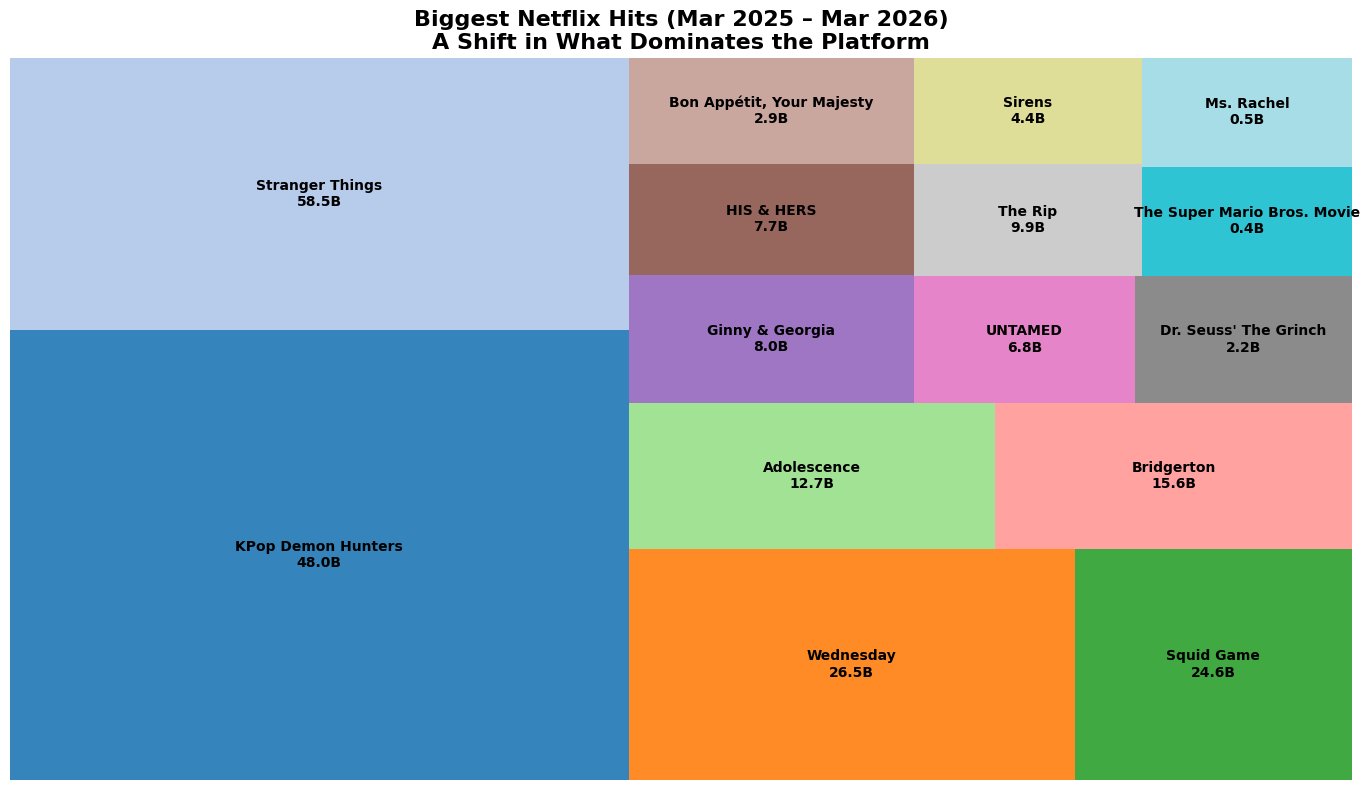

In [46]:
# ==============================
# PREP DATA (labels)
# ==============================
recent_hits = recent_hits.dropna(subset=["total_views", "performance_score"])
recent_hits = recent_hits.sort_values("performance_score", ascending=False)

labels = [
    f"{title}\n{views/1_000_000_000:.1f}B"
    for title, views in zip(recent_hits["show_title"], recent_hits["total_views"])
]

sizes = recent_hits["performance_score"]


# ==============================
# COLOR STRATEGY (HIGH CONTRAST)
# ==============================
cmap = plt.cm.get_cmap("tab20")
colors = [cmap(i) for i in np.linspace(0, 1, len(sizes))]


# ==============================
# PLOT TREEMAP
# ==============================
plt.figure(figsize=(14, 8))

squarify.plot(
    sizes=sizes,
    label=labels,
    color=colors,
    alpha=0.9,
    text_kwargs={"fontsize": 10, "weight": "bold"}
)

plt.title(
    "Biggest Netflix Hits (Mar 2025 – Mar 2026)\nA Shift in What Dominates the Platform",
    fontsize=16,
    weight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Why are these Top Shows a Hit? Why it changed?
| Metric                                       | Source                                  | Type       | Formula                                               | What It Means                                                                    |
| -------------------------------------------- | --------------------------------------- | ---------- | ----------------------------------------------------- | -------------------------------------------------------------------------------- |
| **Weeks in Top 10**                          | Raw data (`cumulative_weeks_in_top_10`) | Extracted  | `MAX(cumulative_weeks_in_top_10)`                     | Total number of weeks a show stayed in the Top 10 → **staying power / survival** |
| **Average Rank**                             | Derived from `weekly_rank`              | Engineered | `AVG(weekly_rank)`                                    | Average position in the Top 10 → **consistency of performance (lower = better)** |
| **Rank Volatility**                          | Derived from `weekly_rank`              | Engineered | `STDDEV(weekly_rank)`                                 | How much the ranking fluctuates → **stability vs spikes (lower = more stable)**  |
| **Total Views** *(optional but useful)*      | Raw (`weekly_views`)                    | Aggregated | `SUM(weekly_views)`                                   | Total audience reach → **scale of success**                                      |
| **Engagement Intensity** *(your key metric)* | Derived                                 | Engineered | `SUM(weekly_views) / MAX(cumulative_weeks_in_top_10)` | Views per week while trending → **how strongly people watch it each week**       |

Do shows win by lasting longer, or by being watched more intensely?



In [54]:
# Build the dataset to explain why those top shows are hits 
why_data = con.execute("""
SELECT
    s.show_title,

    -- Keep if you still want it later
    SUM(f.performance_score) AS performance_score,

    -- Core drivers
    MAX(f.cumulative_weeks_in_top_10) AS weeks_in_top10,
    SUM(f.weekly_views) AS total_views

FROM fact_weekly_performance f
JOIN dim_show s ON f.show_key = s.show_key
JOIN dim_date d ON f.date_key = d.date_key

WHERE d.week_start_date BETWEEN DATE '2025-03-01' AND DATE '2026-03-31'

GROUP BY s.show_title
ORDER BY performance_score DESC
LIMIT 10
""").df()

why_data

,show_title,performance_score,weeks_in_top10,total_views
0,KPop Demon Hunters,45807.493005,39,4.797050e+10
1,Stranger Things,27681.672259,35,5.854600e+10
2,Wednesday,16947.022226,48,2.652270e+10
3,Squid Game,10510.324296,43,2.462140e+10
4,Adolescence,8818.489665,12,1.271520e+10
5,Bridgerton,8568.920900,49,1.562030e+10
6,Ginny & Georgia,5993.217920,13,7.968400e+09
7,HIS & HERS,5228.295521,9,7.745000e+09
8,"Bon Appétit, Your Majesty",4966.172647,12,2.875200e+09
9,UNTAMED,4620.015806,10,6.838900e+09


In [55]:
# They have different scales so must be normalized

why_data["performance_norm"] = why_data["performance_score"] / why_data["performance_score"].max()
why_data["longevity_norm"] = why_data["weeks_in_top10"] / why_data["weeks_in_top10"].max()
why_data["engagement_intensity"] = (why_data["total_views"] / why_data["weeks_in_top10"])

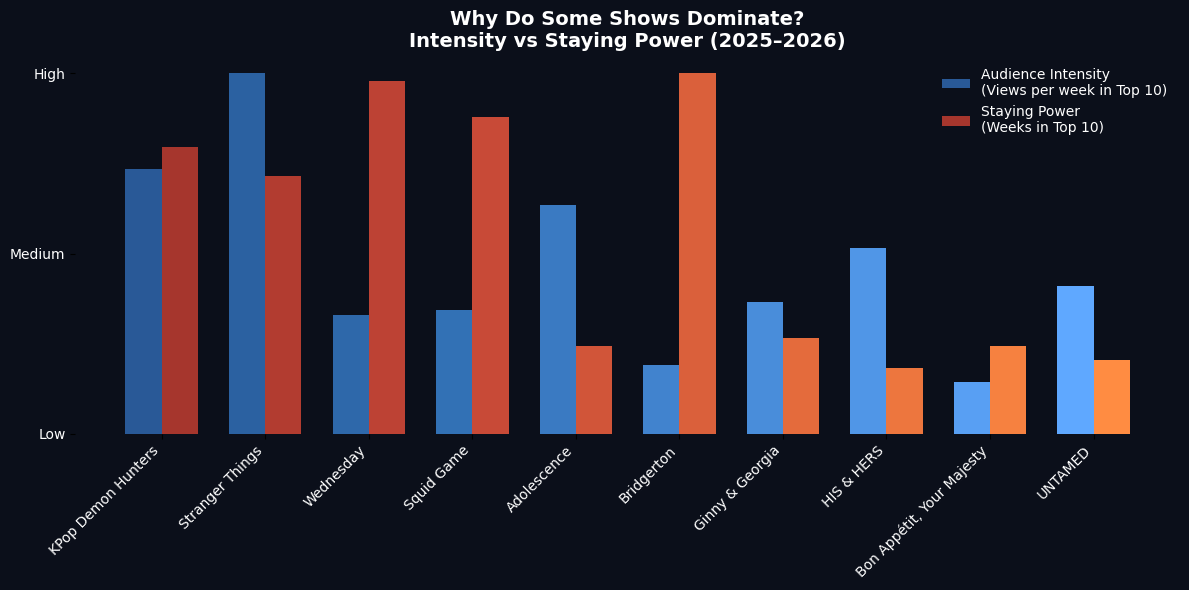

In [61]:
# Gradient for Intensity (blue)
intensity_cmap = LinearSegmentedColormap.from_list(
    "intensity",
    ["#1f3b73", "#2f6db0", "#5fa8ff"]
)

# Gradient for Longevity (orange/red)
longevity_cmap = LinearSegmentedColormap.from_list(
    "longevity",
    ["#7a1f1f", "#c44536", "#ff8c42"]
)

intensity_colors = intensity_cmap(
    np.linspace(0.3, 1, len(why_data))
)

longevity_colors = longevity_cmap(
    np.linspace(0.3, 1, len(why_data))
)

plt.figure(figsize=(12,6), facecolor="#0b0f1a")
ax = plt.gca()
ax.set_facecolor("#0b0f1a")

labels = why_data["show_title"]
x = np.arange(len(labels))
width = 0.35

plt.bar(
    x - width/2,
    why_data["engagement_norm"],
    width,
    color=intensity_colors,
    label="Audience Intensity\n(Views per week in Top 10)"
)

plt.bar(
    x + width/2,
    why_data["longevity_norm"],
    width,
    color=longevity_colors,
    label="Staying Power\n(Weeks in Top 10)"
)

# X-axis
plt.xticks(x, labels, rotation=45, ha="right", color="white")

# Y-axis (your improved version)
plt.yticks([0, 0.5, 1], ["Low", "Medium", "High"], color="white")

# Remove axis label (cleaner)
plt.ylabel("")

# Title
plt.title(
    "Why Do Some Shows Dominate?\n"
    "Intensity vs Staying Power (2025–2026)",
    fontsize=14,
    weight="bold",
    color="white"
)

# Legend
legend = plt.legend(facecolor="#0b0f1a", edgecolor="none")
for text in legend.get_texts():
    text.set_color("white")

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## NEW “HOW SHOWS WINS IN NETFLIX” PERSPECTIVE
- Consistency (Ranking Stability)
- How stable a show’s ranking is week-to-week

| Type           | Example         | Why it wins           |
| -------------- | --------------- | --------------------- |
| 🔴 Blockbuster | Stranger Things | High intensity        |
| 🟢 Evergreen   | Peppa Pig       | Long-term consistency |
| 🔵 Balanced    | Bridgerton      | Both                  |

---

| **Blockbuster (Hype-Driven)**             | **Evergreen (Habit-Driven)**                   |
| ----------------------------------------- | ---------------------------------------------- |
| High spike in views at release            | Steady, consistent views over time             |
| Strong initial demand                     | Lower but stable demand                        |
| Short lifespan in Top 10                  | Long lifespan in Top 10                        |
| Driven by hype and trends                 | Driven by repetition and routine               |
| Typically watched once (binge)            | Frequently rewatched                           |
| Audience drops after peak                 | Audience remains stable                        |
| Examples: *Stranger Things*, *Squid Game* | Examples: *Peppa Pig*, *Lottie Dottie Chicken* |

#### Evergreen
```
ORDER BY weeks_in_top10 DESC
```

#### Blockbusters
```
ORDER BY performance_score DESC
```

In [63]:
# build dataset to show consistency | votality

consistency_data = con.execute("""
SELECT
    s.show_title,

    MAX(f.cumulative_weeks_in_top_10) AS weeks_in_top10,
    AVG(f.weekly_rank) AS avg_rank,
    STDDEV(f.weekly_rank) AS rank_volatility

FROM fact_weekly_performance f
JOIN dim_show s ON f.show_key = s.show_key
JOIN dim_date d ON f.date_key = d.date_key

WHERE d.week_start_date BETWEEN DATE '2025-03-01' AND DATE '2026-03-31'

GROUP BY s.show_title
ORDER BY weeks_in_top10 DESC
LIMIT 20
""").df()

consistency_data

,show_title,weeks_in_top10,avg_rank,rank_volatility
0,Lottie Dottie Chicken,126,8.128205,1.360717
1,Peppa Pig,111,8.276923,1.375087
2,Kitty Kotty,87,8.166667,1.319479
3,Shrek,81,7.957672,1.731531
4,Mai,75,7.684211,2.080869
5,Paw Patrol: The Movie,55,7.829016,1.807619
6,Ms. Rachel,51,7.875576,1.742871
7,Bridgerton,49,3.978372,3.208792
8,Dr. Seuss' The Grinch,48,4.436508,2.855054
9,Wednesday,48,4.170147,3.026785


In [64]:
# Invert volatility (so higher = better)
consistency_data["consistency_score"] = 1 / (1 + consistency_data["rank_volatility"])

# Normalize
consistency_data["consistency_norm"] = (
    consistency_data["consistency_score"] / consistency_data["consistency_score"].max()
)

consistency_data["longevity_norm"] = (
    consistency_data["weeks_in_top10"] / consistency_data["weeks_in_top10"].max()
)

In [67]:
# Thresholds (simple + interpretable)
intensity_threshold = why_data["engagement_norm"].median()
longevity_threshold = why_data["longevity_norm"].median()

def classify(row):
    if row["engagement_norm"] >= intensity_threshold and row["longevity_norm"] < longevity_threshold:
        return "Blockbuster"
    elif row["longevity_norm"] >= longevity_threshold and row["engagement_norm"] < intensity_threshold:
        return "Evergreen"
    else:
        return "Balanced"

why_data["type"] = why_data.apply(classify, axis=1)

blockbuster = why_data[why_data["type"] == "Blockbuster"]
evergreen = why_data[why_data["type"] == "Evergreen"]

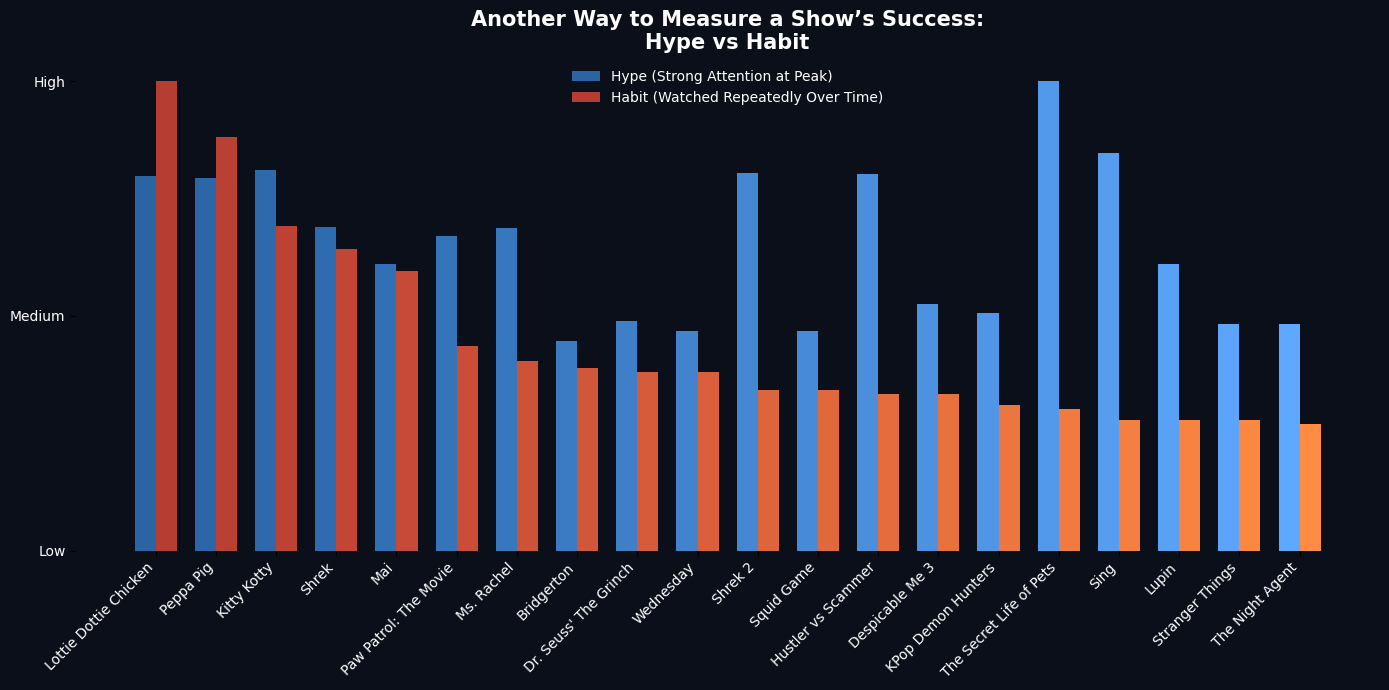

In [70]:
labels = consistency_data["show_title"]
x = np.arange(len(labels))
width = 0.35

# ==============================
# GRADIENT COLORS
# ==============================

# Blue gradient (Hype)
hype_cmap = LinearSegmentedColormap.from_list(
    "hype",
    ["#1f3b73", "#2f6db0", "#5fa8ff"]
)

# Orange gradient (Habit)
habit_cmap = LinearSegmentedColormap.from_list(
    "habit",
    ["#7a1f1f", "#c44536", "#ff8c42"]
)

hype_colors = hype_cmap(np.linspace(0.4, 1, len(labels)))
habit_colors = habit_cmap(np.linspace(0.4, 1, len(labels)))

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(14,7), facecolor="#0b0f1a")
ax = plt.gca()
ax.set_facecolor("#0b0f1a")

plt.bar(
    x - width/2,
    consistency_data["consistency_norm"],
    width,
    color=hype_colors,
    label="Hype (Strong Attention at Peak)"
)

plt.bar(
    x + width/2,
    consistency_data["longevity_norm"],
    width,
    color=habit_colors,
    label="Habit (Watched Repeatedly Over Time)"
)

# X axis
plt.xticks(x, labels, rotation=45, ha="right", color="white")

# Y axis
plt.yticks([0, 0.5, 1], ["Low", "Medium", "High"], color="white")
plt.ylabel("")

# Title
plt.title(
    "Another Way to Measure a Show’s Success:\nHype vs Habit",
    fontsize=15,
    weight="bold",
    color="white"
)

# Legend
legend = plt.legend(facecolor="#0b0f1a", edgecolor="none")
for text in legend.get_texts():
    text.set_color("white")

# Remove borders
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## 3. Global vs Nordics Taste Gap

In [75]:
# ==============================
# STEP 1: BUILD DATASET
# ==============================

taste_gap = con.execute("""
WITH base AS (
    SELECT
        c.country_name,
        s.show_title,
        SUM(f.performance_score) AS perf
    FROM fact_weekly_performance f
    JOIN dim_show s ON f.show_key = s.show_key
    JOIN dim_country c ON f.country_key = c.country_key
    JOIN dim_date d ON f.date_key = d.date_key

    WHERE d.week_start_date BETWEEN DATE '2025-03-01' AND DATE '2026-03-31'

    GROUP BY c.country_name, s.show_title
),

normalized AS (
    SELECT
        country_name,
        show_title,
        perf,
        perf / SUM(perf) OVER (PARTITION BY country_name) AS preference_score
    FROM base
)

SELECT *
FROM normalized
WHERE country_name IN ('Denmark','Finland','Iceland','Norway','Sweden')
""").df()

taste_gap.head()

,country_name,show_title,perf,preference_score
0,Iceland,Olympo,0.693147,0.000095
1,Iceland,Nobody Wants This,40.115410,0.005526
2,Iceland,2 Hearts,1.386294,0.000191
3,Iceland,Cold Case: The Tylenol Murders,11.731386,0.001616
4,Iceland,Take That,2.079442,0.000286


In [76]:
# ==============================
# STEP 2: PIVOT TABLE
# ==============================

pivot = taste_gap.pivot_table(
    index="show_title",
    columns="country_name",
    values="preference_score"
)

# Fill missing values
pivot = pivot.fillna(0)

# Keep only top shows globally (cleaner storytelling)
pivot = pivot.loc[
    pivot.sum(axis=1).sort_values(ascending=False).head(10).index
]

pivot

country_name,Denmark,Finland,Iceland,Norway,Sweden
show_title,,,,,
KPop Demon Hunters,0.080473,0.067286,0.063351,0.066914,0.087135
Stranger Things,0.025220,0.029218,0.032088,0.019733,0.027664
Wednesday,0.024785,0.023869,0.020420,0.021317,0.021620
Adolescence,0.020460,0.016013,0.013196,0.019013,0.018583
Bridgerton,0.013912,0.014272,0.011698,0.015894,0.013339
Dept. Q,0.010799,0.009671,0.015205,0.016229,0.014995
PAW Patrol: The Mighty Movie,0.013009,0.010567,0.023669,0.007412,0.008307
Fireplace for Your Home: Crackling Birchwood Fireplace,0.018486,0.002130,0.010404,0.005321,0.024024
UNTAMED,0.011824,0.010882,0.010283,0.012362,0.011336


In [85]:
# ==============================
# STEP 3: PERCENTILE BINNING
# ==============================

import pandas as pd

melted = pivot.reset_index().melt(
    id_vars="show_title",
    var_name="country",
    value_name="score"
)

# Create categories (Low / Medium / High)
melted["category"] = pd.qcut(
    melted["score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Back to matrix
heatmap_labels = melted.pivot(
    index="show_title",
    columns="country",
    values="category"
)

In [88]:
# ==============================
# STEP 4: MAP TO NUMERIC 
# ==============================

mapping = {"Low": 0, "Medium": 1, "High": 2}

numeric_labels = heatmap_labels.apply(lambda col: col.map(mapping)).astype(float)

In [90]:
# ==============================
# STEP: SORT BY IMPORTANCE
# ==============================

# Create ranking score per show
row_score = numeric_labels.sum(axis=1)

# Sort pivot + labels together
pivot_sorted = pivot.loc[row_score.sort_values(ascending=False).index]
labels_sorted = heatmap_labels.loc[pivot_sorted.index]
numeric_sorted = numeric_labels.loc[pivot_sorted.index]

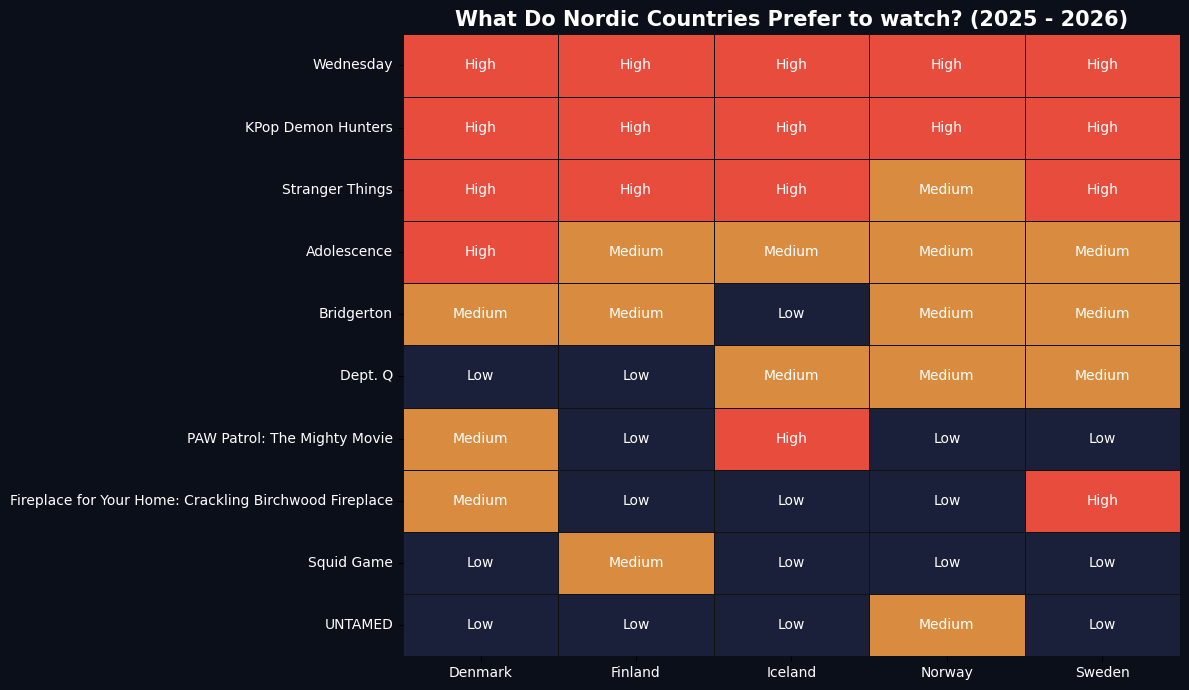

In [ ]:
# ==============================
# STEP 5: VISUALIZATION
# ==============================


# Custom dark palette
cmap = ListedColormap([
    "#1a1f3a",  # Low
    "#d98c3f",  # Medium
    "#e84c3d"   # High
])

plt.figure(figsize=(12,7), facecolor="#0b0f1a")
ax = plt.gca()
ax.set_facecolor("#0b0f1a")

sns.heatmap(
    numeric_sorted,
    cmap=cmap,
    annot=labels_sorted,
    fmt="",
    cbar=False,
    linewidths=0.5,
    linecolor="#111"
)

# Title
plt.title(
    "ComWhat Do Nordic Countries Prefer to watch? (2025 - 2026)",
    fontsize=15,
    weight="bold",
    color="white"
)

# Clean axes
plt.xlabel("")
plt.ylabel("")

plt.xticks(color="white")
plt.yticks(color="white")

# Remove borders
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## 4. What top 3 genres dominate in each Nordic country?

In [139]:
preference_df = con.execute("""
WITH base AS (
    SELECT
        c.country_name,
        b.genre,
        SUM(f.weekly_hours_viewed) AS hours
    FROM fact_weekly_performance f
    JOIN dim_show s ON f.show_key = s.show_key
    JOIN bridge_show_genre b ON s.show_key = b.show_key
    JOIN dim_country c ON f.country_key = c.country_key
    JOIN dim_date d ON f.date_key = d.date_key

    WHERE d.week_start_date BETWEEN DATE '2025-03-01' AND DATE '2026-03-31'
      AND c.country_name IN ('Denmark','Finland','Iceland','Norway','Sweden')

    GROUP BY c.country_name, b.genre
),

country_total AS (
    SELECT
        country_name,
        SUM(hours) AS total_country_hours
    FROM base
    GROUP BY country_name
),

global_total AS (
    SELECT
        genre,
        SUM(hours) AS total_global_hours
    FROM base
    GROUP BY genre
),

global_sum AS (
    SELECT
        SUM(total_global_hours) AS grand_total
    FROM global_total
)

SELECT
    b.country_name,
    b.genre,
    (b.hours / ct.total_country_hours) /
    (gt.total_global_hours / gs.grand_total) AS preference_ratio
FROM base b
JOIN country_total ct ON b.country_name = ct.country_name
JOIN global_total gt ON b.genre = gt.genre
JOIN global_sum gs ON TRUE
""").df()

preference_df

,country_name,genre,preference_ratio
0,Norway,Animation,1.023524
1,Norway,Biography,1.076895
2,Norway,Documentary,1.037112
3,Finland,Animation,0.955970
4,Finland,Biography,0.990349
...,...,...,...
109,Iceland,History,0.804788
110,Norway,Romance,1.110159
111,Norway,History,0.898013
112,Denmark,Romance,1.041976


In [148]:
top3 = (
    preference_df
    .sort_values(["country_name", "preference_ratio"], ascending=[True, False])
    .groupby("country_name")
    .head(3)
)

top3["scaled"] = top3.groupby("country_name")["preference_ratio"].transform(
    lambda x: x / x.sum()
)

# keep only columns actually used (non-zero)
pivot_top3 = pivot_top3.loc[:, (pivot_top3 > 0).any(axis=0)]

In [149]:
colors = [
    "#4ea8de",  # soft blue
    "#5390d9",
    "#5e60ce",
    "#48bfe3",
    "#56cfe1",
    "#64dfdf",
    "#ff7b54",  # accent orange
    "#ff9f1c",
]

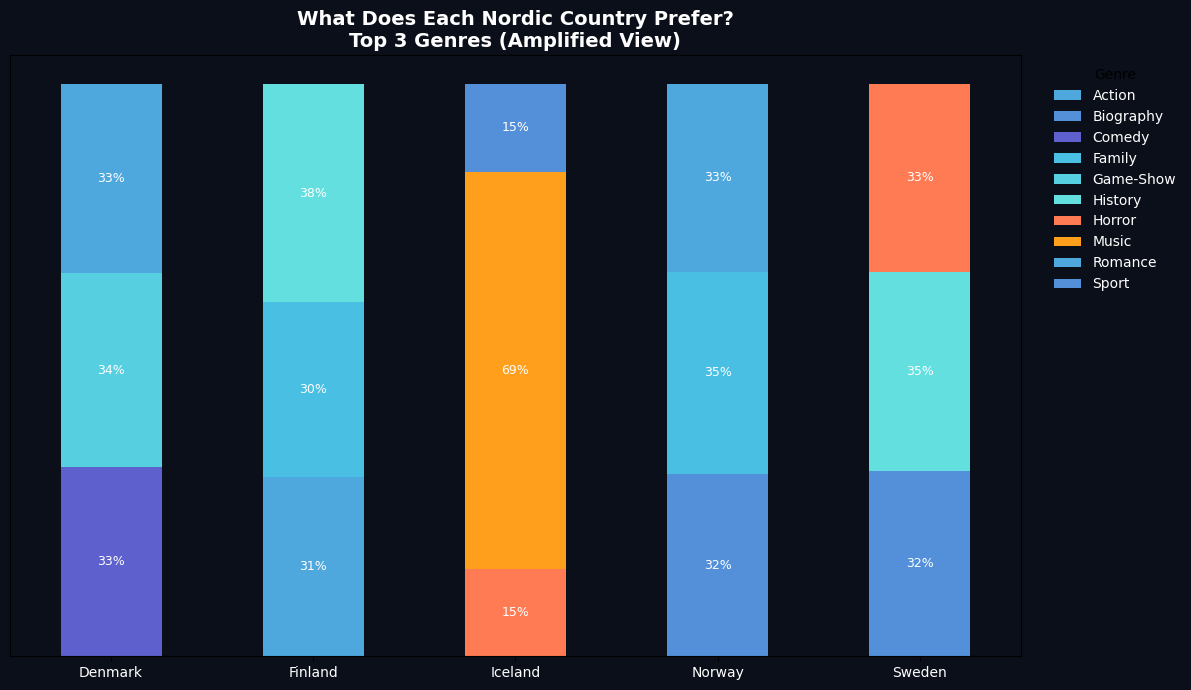

In [150]:
plt.figure(figsize=(12, 7), facecolor="#0b0f1a")
ax = plt.gca()
ax.set_facecolor("#0b0f1a")

pivot_top3.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors[:len(pivot_top3.columns)]
)

# Add % labels
for i, country in enumerate(pivot_top3.index):
    cumulative = 0
    for genre in pivot_top3.columns:
        value = pivot_top3.loc[country, genre]
        if value > 0:
            ax.text(
                i,
                cumulative + value / 2,
                f"{value:.0%}",
                ha="center",
                va="center",
                fontsize=9,
                color="white"
            )
            cumulative += value

# Clean styling
plt.title(
    "What Does Each Nordic Country Prefer?\nTop 3 Genres (Amplified View)",
    fontsize=14,
    weight="bold",
    color="white"
)

plt.xticks(rotation=0, color="white")
plt.yticks([])
plt.xlabel("")
plt.ylabel("")

# Clean legend (only used genres now)
plt.legend(
    title="Genre",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    labelcolor="white"
)

plt.tight_layout()
plt.show()

In [151]:
preference_df_2 = con.execute("""
SELECT
    c.country_name,
    b.genre,
    SUM(f.weekly_hours_viewed) AS total_hours

FROM fact_weekly_performance f
JOIN dim_show s 
    ON f.show_key = s.show_key
JOIN bridge_show_genre b 
    ON s.show_key = b.show_key
JOIN dim_country c 
    ON f.country_key = c.country_key
JOIN dim_date d 
    ON f.date_key = d.date_key

WHERE d.week_start_date BETWEEN DATE '2025-03-01' AND DATE '2026-03-31'
AND c.country_name IN ('Denmark','Finland','Iceland','Norway','Sweden')

GROUP BY c.country_name, b.genre
""").df()

preference_df_2.head()

,country_name,genre,total_hours
0,Iceland,Family,2.151000e+08
1,Iceland,Mystery,3.742600e+09
2,Sweden,Thriller,3.028000e+09
3,Finland,Sport,4.916000e+08
4,Sweden,Sci-Fi,4.818000e+08


In [152]:
preference_df_2.sort_values("total_hours", ascending=False).head(10)

,country_name,genre,total_hours
38,Finland,Drama,1.759210e+10
50,Sweden,Drama,1.653820e+10
26,Denmark,Drama,1.638460e+10
91,Iceland,Drama,1.636010e+10
11,Norway,Drama,1.585710e+10
36,Finland,Crime,9.181000e+09
49,Sweden,Crime,8.645600e+09
25,Denmark,Crime,8.640000e+09
16,Norway,Crime,8.595500e+09
88,Iceland,Crime,8.156500e+09


In [153]:
top3 = preference_df_2.groupby("country_name").apply(
    lambda x: x.nlargest(3, "total_hours")
).reset_index(drop=True)

top3

C:\Users\adelo\AppData\Local\Temp\ipykernel_19908\2109161005.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3 = preference_df_2.groupby("country_name").apply(


,country_name,genre,total_hours
0,Denmark,Drama,1.638460e+10
1,Denmark,Crime,8.640000e+09
2,Denmark,Comedy,5.730600e+09
3,Finland,Drama,1.759210e+10
4,Finland,Crime,9.181000e+09
5,Finland,Comedy,5.716300e+09
6,Iceland,Drama,1.636010e+10
7,Iceland,Crime,8.156500e+09
8,Iceland,Comedy,5.802500e+09
9,Norway,Drama,1.585710e+10


In [154]:
pivot = top3.pivot(
    index="country_name",
    columns="genre",
    values="total_hours"
).fillna(0)

pivot

genre,Comedy,Crime,Drama,Fantasy
country_name,,,,
Denmark,5.730600e+09,8.640000e+09,1.638460e+10,0.000000e+00
Finland,5.716300e+09,9.181000e+09,1.759210e+10,0.000000e+00
Iceland,5.802500e+09,8.156500e+09,1.636010e+10,0.000000e+00
Norway,5.268200e+09,8.595500e+09,1.585710e+10,0.000000e+00
Sweden,0.000000e+00,8.645600e+09,1.653820e+10,5.398000e+09


In [155]:
color_map = {
    "Drama": "#FF4C4C",
    "Crime": "#FFA500",
    "Comedy": "#00C2FF",
    "Action": "#00FF9C",
    "Family": "#FFD700",
    "Game-Show": "#8A2BE2",
    "History": "#FF69B4",
    "Sport": "#00BFFF",
    "Biography": "#A0522D",
    "Horror": "#FF0033"
}

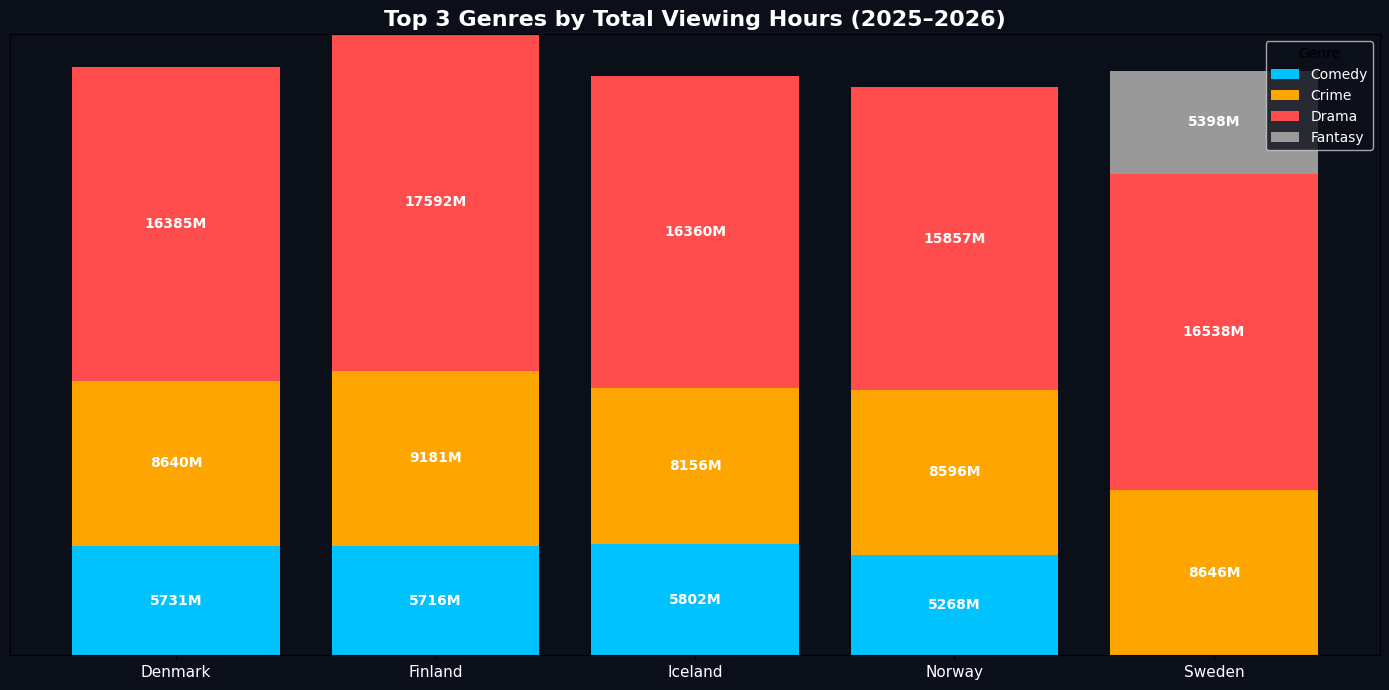

In [160]:
plt.figure(figsize=(14,7), facecolor="#0b0f1a")
ax = plt.gca()
ax.set_facecolor("#0b0f1a")

bottom = np.zeros(len(pivot))

for genre in pivot.columns:
    values = pivot[genre].values

    ax.bar(
        pivot.index,
        values,
        bottom=bottom,
        label=genre,
        color=color_map.get(genre, "#999999")
    )

    # 🔥 LABELS (REAL NUMBERS IN MILLIONS)
    for i, v in enumerate(values):
        if v > 0:
            ax.text(
                i,
                bottom[i] + v/2,
                f"{v/1e6:.0f}M",
                ha='center',
                va='center',
                color="white",
                fontsize=10,
                weight="bold"
            )

    bottom += values

# Remove clutter
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

plt.xticks(color="white", fontsize=11)

plt.title(
    "Top 3 Genres by Total Viewing Hours (2025–2026)",
    color="white",
    fontsize=16,
    weight="bold"
)

plt.legend(
    title="Genre",
    facecolor="#0b0f1a",
    labelcolor="white"
)

plt.tight_layout()
plt.show()

In [157]:
preference_df_2.groupby("country_name")["total_hours"].sum()

country_name
Denmark    6.572470e+10
Finland    6.888450e+10
Iceland    6.521670e+10
Norway     6.337960e+10
Sweden     6.623540e+10
Name: total_hours, dtype: float64

In [158]:
preference_df_2.sort_values(
    ["country_name", "total_hours"],
    ascending=[True, False]
).groupby("country_name").head(5)

,country_name,genre,total_hours
26,Denmark,Drama,1.638460e+10
25,Denmark,Crime,8.640000e+09
46,Denmark,Comedy,5.730600e+09
79,Denmark,Fantasy,5.100800e+09
32,Denmark,Action,4.774200e+09
38,Finland,Drama,1.759210e+10
36,Finland,Crime,9.181000e+09
15,Finland,Comedy,5.716300e+09
75,Finland,Fantasy,5.283900e+09
92,Finland,Action,5.283000e+09
